# GuarantorLens - loan-default risk with a guarantor network

This notebook builds the whole modelling pipeline on the real
**11-branch** loan data, **honestly and step by step**: it names the label, removes leakage on
the borrower and the network side, describes the data, tunes five model families with grid
search, handles the class imbalance, checks whether the guarantor network adds signal, explains
the model with SHAP, makes the scores realistic and calibrated, tests the final model on worked
cases, and exports an artifact the app serves.

## Setting Up and loading the data



In [1]:
import warnings, os, json, shutil
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from bisect import bisect_left

RANDOM_STATE = 42
COHORT_START, COHORT_END = "2022-01-01", "2023-12-31"   # the disbursement window we were given
TARGET_RECALL = 0.80
NORMAL_FILE, WRITTENOFF_FILE = "Normal.xlsx", "Written Off.xlsx"

try:
    from google.colab import files
    ON_COLAB = True
except Exception:
    ON_COLAB = False

if ON_COLAB:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "xgboost", "imbalanced-learn", "shap", "openpyxl"])
    DATASET_DIR = Path(".")
    have = {p.name for p in DATASET_DIR.glob("*.xlsx")}
    if not ({NORMAL_FILE, WRITTENOFF_FILE} <= have):
        print("Upload BOTH files: 'Normal.xlsx' and 'Written Off.xlsx'")
        files.upload()
else:
    DATASET_DIR = Path("data/Dataset")

OUTPUT_DIR = Path("models/guarantorlens_new"); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for f in (NORMAL_FILE, WRITTENOFF_FILE):
    assert (DATASET_DIR / f).exists(), f"Missing {f}. On Colab, re-run and upload it."
print("data folder:", DATASET_DIR.resolve())
# --- clearer, larger figures for the report ---
plt.rcParams.update({
    'font.size': 12, 'axes.titlesize': 13, 'axes.labelsize': 12,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 10,
    'figure.dpi': 110, 'savefig.dpi': 160, 'savefig.bbox': 'tight',
})


# --- save every printed line to a run log (shown AND written to disk) ---
import sys as _sys
class _Tee:
    def __init__(self, path):
        self._term = _sys.__stdout__; self._log = open(path, "w", encoding="utf-8")
    def write(self, s): self._term.write(s); self._log.write(s); self._log.flush()
    def flush(self):
        self._term.flush(); self._log.flush()
    def isatty(self): return False
LOG_PATH = OUTPUT_DIR / "run_log.txt"
_sys.stdout = _Tee(str(LOG_PATH))
print("run log ->", LOG_PATH)

Upload BOTH files: 'Normal.xlsx' and 'Written Off.xlsx'


##  The label, and features we are allowed to use

A loan in `Written Off.xlsx` is a **default (1)**; a loan in `Normal.xlsx`
is **good (0)**. (Repayment Status inside the files is only the *recovery* state - a write-off
that was later repaid is still a write-off, so we never use it as the label.)

Some columns only exist *after* the loan is decided (arrears, repayment status, unpaid amounts,
last payment date). Using them would be cheating, so we drop them and keep only what an officer
knows **on the day the loan is given**.

In [2]:
OUTCOME_COLS = ["Days in Arrears","Repayment Status","Non Paid Capital","Non Paid Interest",
                "Non Paid Penalty","Non Paid Insurance","Last Payment Date"]

# leak-free individual (borrower/loan) features, all known at origination
IND_CANDIDATES = ["log_amount","savings","salary","interest_rate","loan_to_savings",
                  "loan_to_salary","account_age","b_prior_loans","b_prior_writeoff",
                  "b_prior_arrears_rate","time_since_last_loan","b_recent_loans"]
# candidate guarantor-network features (screened for time leakage below)
NET_CANDIDATES = ["n_guarantors","g_mean_savings","g_mean_salary","g_prior_default_rate",
                  "g_prior_arrears_rate","g_sav_ratio","community_prior_default_rate"]

## Load the two files (dataset)

Each row is one **(loan, guarantor)** pair. We tag the label by file, read the branch from the
`Branch Name` column, and if a loan somehow appears in both files the **write-off wins**.

In [3]:
def load_labeled(path, label):
    xl = pd.ExcelFile(path)
    d = pd.concat([pd.read_excel(path, sheet_name=s) for s in xl.sheet_names], ignore_index=True)
    d["label"] = label
    return d

normal = load_labeled(DATASET_DIR / NORMAL_FILE, 0)
writ   = load_labeled(DATASET_DIR / WRITTENOFF_FILE, 1)
normal = normal[~normal["Loan ID"].isin(set(writ["Loan ID"]))]   # write-off wins on overlap
raw = pd.concat([normal, writ], ignore_index=True)
raw["branch"] = raw["Branch Name"].astype(str).str.strip()
for c in ["Disbursement Date","Customer Opening Date"]:
    raw[c] = pd.to_datetime(raw[c], errors="coerce")
for c in ["Disbursement Amount","Savings","Salary","Interest Rate","Days in Arrears"]:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")
print("rows:", len(raw), "| loans:", raw['Loan ID'].nunique(), "| branches:", raw['branch'].nunique())

## One row per loan

We collapse to one row per loan with its list of guarantors, and a `troubled` flag (written off,
or 30+ days in arrears) that we only ever read for a member's **earlier** loans, so it stays
leak-free.

In [4]:
agg = {"Borrower ID":"first","branch":"first","label":"first","Disbursement Amount":"first",
       "Disbursement Date":"first","Customer Opening Date":"first","Savings":"first",
       "Salary":"first","Interest Rate":"first","Days in Arrears":"first"}
loans = raw.groupby("Loan ID").agg(agg).reset_index()
guar = raw.groupby("Loan ID")["Guarantor ID"].apply(lambda s: [x for x in s.dropna().unique()])
loans["guarantors"] = loans["Loan ID"].map(guar.to_dict())
loans["n_guarantors"] = loans["guarantors"].apply(len)
loans["troubled"] = ((loans.label == 1) | (loans["Days in Arrears"] >= 30)).astype(int)

by = loans.groupby(loans.label.map({0:"Normal",1:"Written off"}))["n_guarantors"].agg(["size","median","mean"])
print("guarantors per loan by outcome:"); print(by.to_string())
print(f"\nloans={len(loans)}  defaults={loans.label.sum()}  bad_rate={loans.label.mean():.1%}  branches={loans.branch.nunique()}")

## Building the features

For every loan we only look at each member's **earlier** loans, never later ones. Borrower
features come from their own history; guarantor features from each guarantor's own record and the
loans they had already backed. We also build a **community** feature: the past default rate of the
borrower's wider guarantee cluster (connected component in the guarantee graph), computed as-of.

In [5]:
# --- guarantee graph -> communities (union-find) ---
parent = {}
def find(x):
    parent.setdefault(x, x)
    while parent[x] != x: parent[x] = parent[parent[x]]; x = parent[x]
    return x
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb: parent[ra] = rb
for _, r in loans.iterrows():
    for g in r["guarantors"]: union(r["Borrower ID"], g)
loans["comm"] = loans["Borrower ID"].map(find)

# per-community time-sorted (date,label) for an AS-OF community default rate (leak-free)
comm_hist = {}
for _, r in loans.iterrows():
    comm_hist.setdefault(find(r["Borrower ID"]), []).append((r["Disbursement Date"], r["label"]))
for c in comm_hist: comm_hist[c] = sorted((d, l) for d, l in comm_hist[c] if pd.notna(d))
def comm_prior_rate(comm, d):
    h = comm_hist.get(comm, [])
    if not h or pd.isna(d): return np.nan
    earlier = [l for dd, l in h[:bisect_left([x[0] for x in h], d)]]
    return float(np.mean(earlier)) if earlier else np.nan

# --- member histories (as-of) ---
bmap = loans.groupby("Borrower ID").agg(sav=("Savings","median"), sal=("Salary","median")).to_dict("index")
member_loans, guar_backed = {}, {}
for _, r in loans.iterrows():
    member_loans.setdefault(r["Borrower ID"], []).append((r["Disbursement Date"], r["label"], r["troubled"]))
    for g in r["guarantors"]:
        guar_backed.setdefault(g, []).append((r["Disbursement Date"], r["troubled"]))
def earlier(mid, d):
    return [(dt, lb, tr) for dt, lb, tr in member_loans.get(mid, []) if pd.notna(dt) and pd.notna(d) and dt < d]
def earlier_backed(g, d):
    return [(dt, tr) for dt, tr in guar_backed.get(g, []) if pd.notna(dt) and pd.notna(d) and dt < d]

rows = []
for _, r in loans.iterrows():
    d, amt, sav, sal, gs = r["Disbursement Date"], r["Disbursement Amount"], r["Savings"], r["Salary"], r["guarantors"]
    gsav = [bmap[g]["sav"] for g in gs if g in bmap]; gsal = [bmap[g]["sal"] for g in gs if g in bmap]
    gms = float(np.mean(gsav)) if gsav else np.nan
    age = ((d - r["Customer Opening Date"]).days/365.25) if pd.notna(d) and pd.notna(r["Customer Opening Date"]) else np.nan
    ph = earlier(r["Borrower ID"], d); last = max([dt for dt,_,_ in ph]) if ph else None
    gdf, gba = [], []
    for g in gs:
        gdf.append(int(any(lb == 1 for _, lb, _ in earlier(g, d))))
        bk = earlier_backed(g, d); gba.append(float(np.mean([t for _, t in bk])) if bk else 0.0)
    rows.append(dict(
        loan=r["Loan ID"], borrower=r["Borrower ID"], label=r["label"], branch=r["branch"], disb_date=d,
        log_amount=np.log1p(amt), savings=sav, salary=sal, interest_rate=r["Interest Rate"],
        loan_to_savings=amt/max(sav,1.0) if pd.notna(sav) else np.nan,
        loan_to_salary=amt/max(sal,1.0) if pd.notna(sal) else np.nan,
        account_age=age, b_prior_loans=len(ph), b_prior_writeoff=int(any(lb==1 for _,lb,_ in ph)),
        b_prior_arrears_rate=float(np.mean([t for _,_,t in ph])) if ph else 0.0,
        time_since_last_loan=((d-last).days/365.25) if last else np.nan,
        b_recent_loans=sum(1 for dt,_,_ in ph if (d-dt).days <= 730),
        n_guarantors=len(gs), g_mean_savings=gms, g_mean_salary=float(np.mean(gsal)) if gsal else np.nan,
        g_prior_default_rate=float(np.mean(gdf)) if gs else 0.0,
        g_prior_arrears_rate=float(np.mean(gba)) if gs else 0.0,
        g_sav_ratio=(gms/(max(sav,0.0)+1)) if (gsav and pd.notna(sav)) else np.nan,
        community_prior_default_rate=comm_prior_rate(r["comm"], d)))
df = pd.DataFrame(rows)
print("feature table:", df.shape, "| communities:", loans['comm'].nunique())
df[IND_CANDIDATES + NET_CANDIDATES].describe().T[["mean","min","50%","max"]].round(2)

,mean,min,50%,max
log_amount,14.49,10.31,14.40,16.12
savings,374229.82,-979254.00,229152.00,7670930.00
salary,171937.30,12.00,142224.00,2600000.00
interest_rate,13.12,11.00,13.00,14.00
loan_to_savings,7580.57,0.06,8.73,3500000.00
loan_to_salary,38.72,0.18,13.59,282500.00
account_age,7.70,0.00,7.34,43.02
b_prior_loans,0.00,0.00,0.00,1.00
b_prior_writeoff,0.00,0.00,0.00,1.00
b_prior_arrears_rate,0.00,0.00,0.00,1.00


## Cohort and leakage screeninhg

All loans are disbursed **2022-2023** (the matured window we were given). We then screen every
feature for a **hidden clock**: if a feature tracks the disbursement date too strongly it is a
disguised time-leak, so we drop it. (`time_since_last_loan` fails this and is dropped.)

In [6]:
from sklearn.metrics import roc_auc_score
cohort = df[(df.disb_date >= COHORT_START) & (df.disb_date <= COHORT_END)].copy().reset_index(drop=True)
print(f"MATURED COHORT {COHORT_START}..{COHORT_END}: loans={len(cohort)} defaults={cohort.label.sum()} rate={cohort.label.mean():.1%}")

dnum = cohort.disb_date.astype("int64"); DATE_LEAK = 0.40
screen = []
for c in IND_CANDIDATES + NET_CANDIDATES:
    x = cohort[c]; m = x.notna()
    try: auc = roc_auc_score(cohort.label[m], x[m])
    except Exception: auc = np.nan
    corr = np.corrcoef(x[m], dnum[m])[0,1] if m.sum() > 2 else np.nan
    screen.append(dict(feature=c, single_auc=round(auc,3), date_corr=round(corr,2),
                       group="network" if c in NET_CANDIDATES else "individual"))
screen = pd.DataFrame(screen)
dropped = screen[screen.date_corr.abs() > DATE_LEAK].feature.tolist()
IND_FEATURES = [c for c in IND_CANDIDATES if c not in dropped]
NET_FEATURES = [c for c in NET_CANDIDATES if c not in dropped]
FULL_FEATURES = IND_FEATURES + NET_FEATURES
print("\nleakage screen (|date_corr|>0.40 = dropped):"); print(screen.to_string(index=False))
print(f"\nDROPPED as time-proxy: {dropped}\nkept: {len(FULL_FEATURES)} features")

## Visual evidence

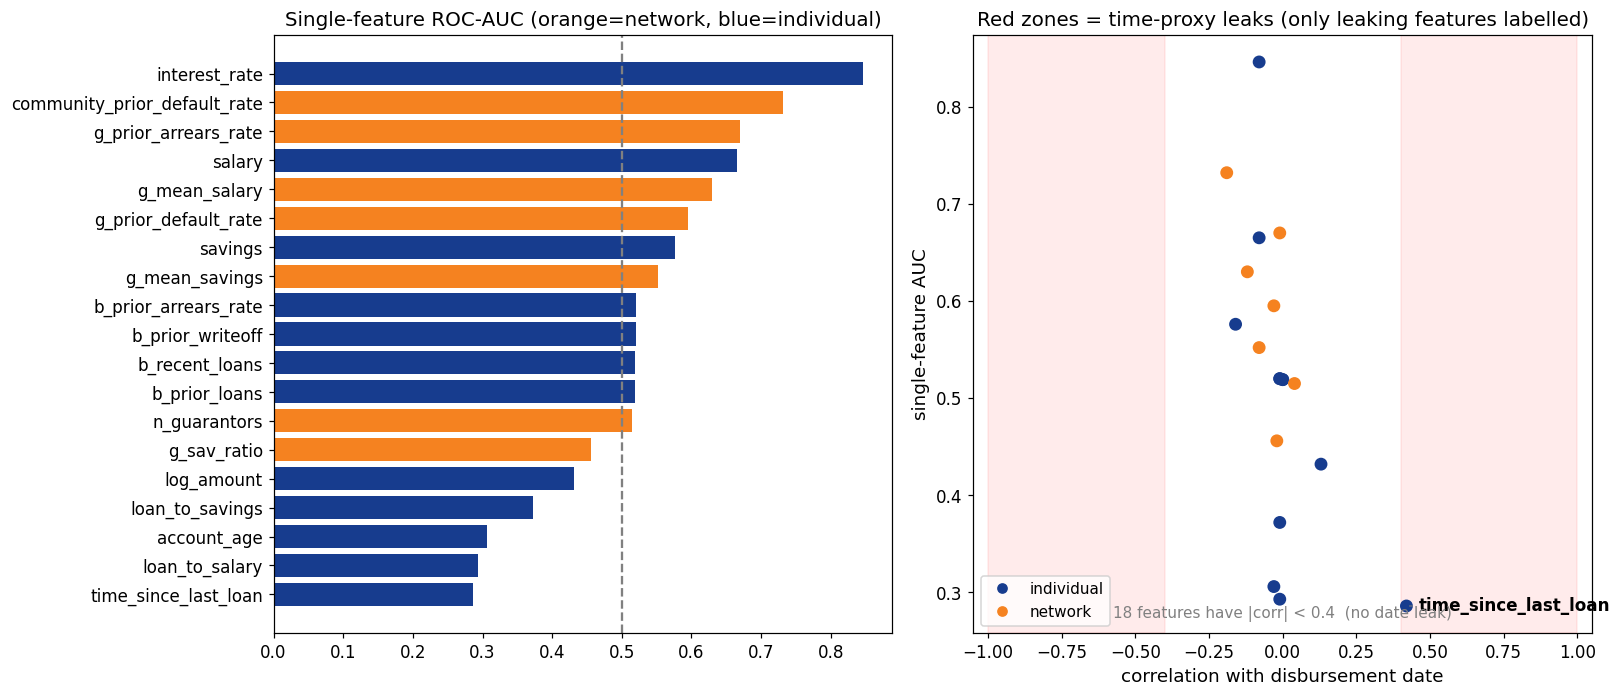

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6.5))
sc = screen.sort_values("single_auc")
colors = ["#F58220" if g=="network" else "#173C8E" for g in sc.group]
ax[0].barh(sc.feature, sc.single_auc, color=colors); ax[0].axvline(0.5, ls="--", c="grey")
ax[0].set_title("Single-feature ROC-AUC (orange=network, blue=individual)")

# Right panel = date-leak check. Only features that fall inside a red zone are labelled;
# the left panel already names every feature, so the cluster near 0 stays uncluttered.
pt_colors = ["#F58220" if g=="network" else "#173C8E" for g in screen.group]
ax[1].scatter(screen.date_corr, screen.single_auc, c=pt_colors, s=55, zorder=3)
ax[1].axvspan(-1, -0.4, color="red", alpha=0.08); ax[1].axvspan(0.4, 1, color="red", alpha=0.08)
leaks = screen[screen.date_corr.abs() >= 0.4]
for _, r in leaks.iterrows():
    ax[1].annotate(r.feature, (r.date_corr, r.single_auc),
                   xytext=(8, 0), textcoords="offset points", fontsize=11,
                   va="center", fontweight="bold",
                   arrowprops=dict(arrowstyle="-", color="grey", lw=0.7))
ax[1].text(0.0, 0.02, f"{len(screen) - len(leaks)} features have |corr| < 0.4  (no date leak)",
           transform=ax[1].get_xaxis_transform(), ha="center", va="bottom", fontsize=10, color="grey")
from matplotlib.lines import Line2D
ax[1].legend(handles=[Line2D([0], [0], marker="o", ls="", color="#173C8E", label="individual"),
                      Line2D([0], [0], marker="o", ls="", color="#F58220", label="network")],
             loc="lower left", fontsize=10)
ax[1].set_xlim(-1.05, 1.05)
ax[1].set_xlabel("correlation with disbursement date"); ax[1].set_ylabel("single-feature AUC")
ax[1].set_title("Red zones = time-proxy leaks (only leaking features labelled)")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"01_leakage_evidence.png", dpi=160); plt.show()

## class imbalance and feature spread

Defaults are rare (the **class imbalance** below), which is why we score with PR-AUC and handle
imbalance later. The other panels show how loan-to-savings and the interest rate separate good
from bad loans, and how the features relate to each other.

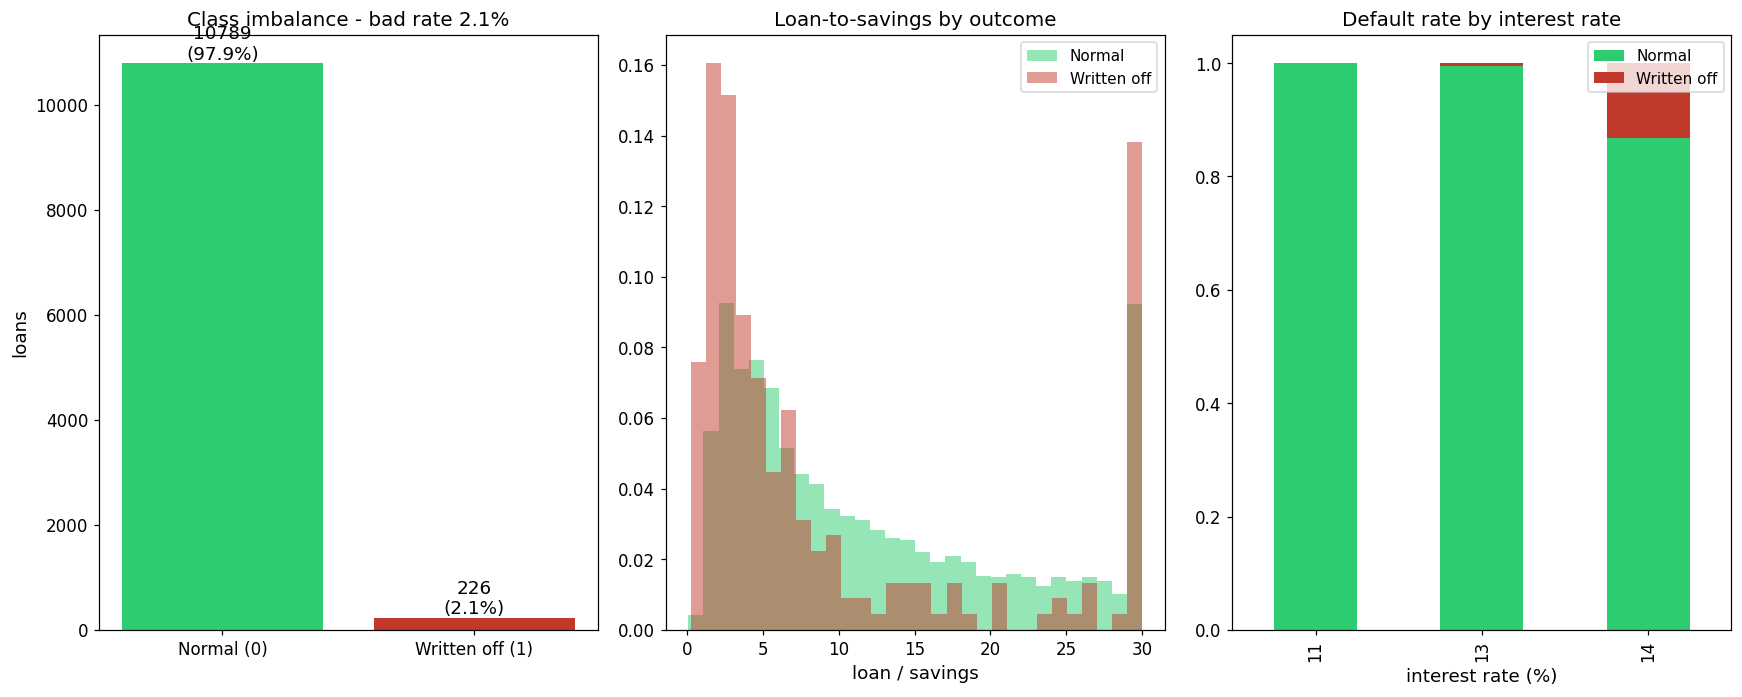

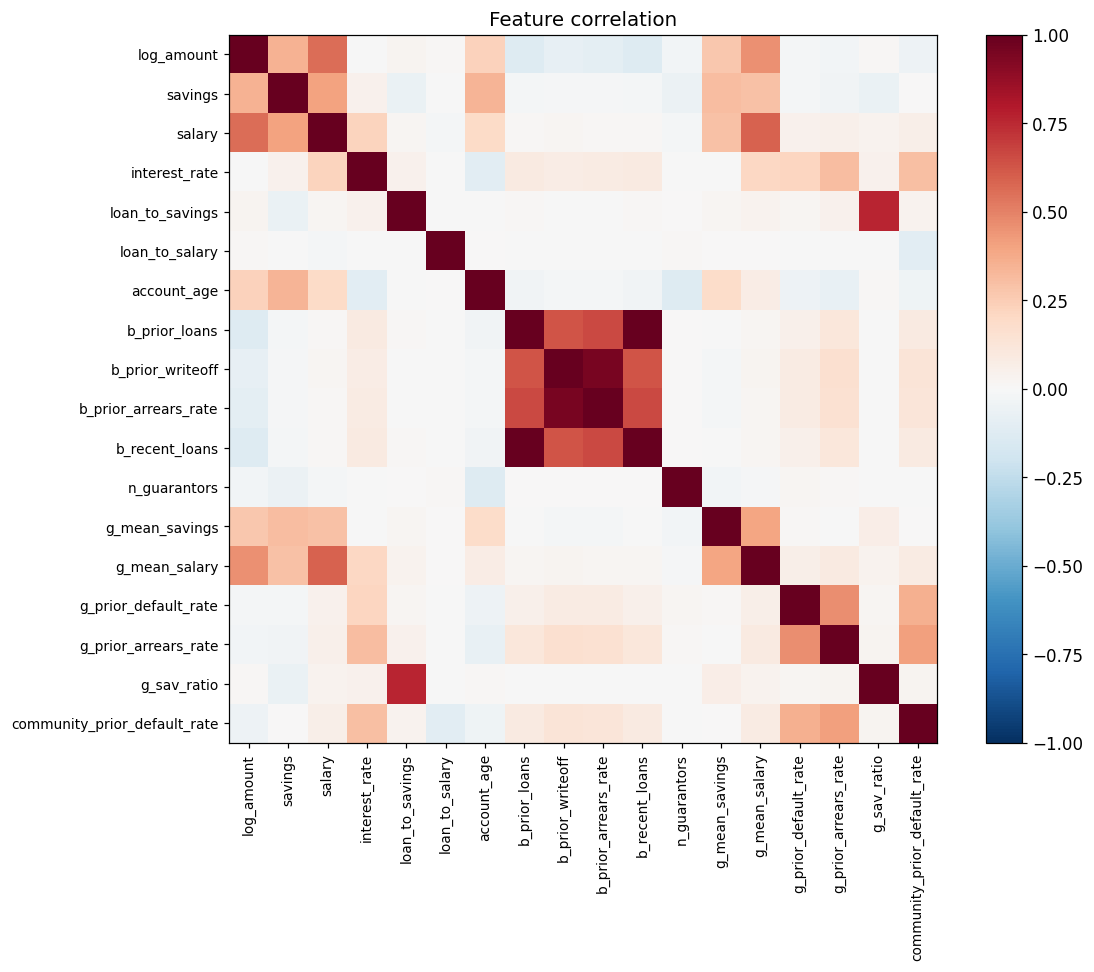

In [8]:
lab = cohort.label
fig, ax = plt.subplots(1, 3, figsize=(16, 6.5))
vc = lab.value_counts().sort_index()
ax[0].bar(["Normal (0)","Written off (1)"], vc.values, color=["#2ecc71","#c0392b"])
for i,v in enumerate(vc.values): ax[0].text(i, v, f"{v}\n({v/len(lab):.1%})", ha="center", va="bottom")
ax[0].set_title(f"Class imbalance - bad rate {lab.mean():.1%}"); ax[0].set_ylabel("loans")
for lv,c,nm in [(0,"#2ecc71","Normal"),(1,"#c0392b","Written off")]:
    ax[1].hist(cohort.loc[lab==lv,"loan_to_savings"].clip(upper=30), bins=30, alpha=0.5, color=c, label=nm, density=True)
ax[1].set_title("Loan-to-savings by outcome"); ax[1].set_xlabel("loan / savings"); ax[1].legend()
ct = pd.crosstab(cohort.interest_rate.round(), lab, normalize="index")
ct.plot(kind="bar", stacked=True, ax=ax[2], color=["#2ecc71","#c0392b"]); ax[2].set_title("Default rate by interest rate")
ax[2].set_xlabel("interest rate (%)"); ax[2].legend(["Normal","Written off"], fontsize=10)
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"07_data_overview.png", dpi=160); plt.show()
print("class counts:"); print(lab.map({0:"Normal",1:"Written off"}).value_counts().to_string())

fig, axc = plt.subplots(figsize=(11, 9)); corr = cohort[FULL_FEATURES].corr()
im = axc.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axc.set_xticks(range(len(FULL_FEATURES))); axc.set_xticklabels(FULL_FEATURES, rotation=90, fontsize=9)
axc.set_yticks(range(len(FULL_FEATURES))); axc.set_yticklabels(FULL_FEATURES, fontsize=9)
plt.colorbar(im, fraction=0.046); axc.set_title("Feature correlation"); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"07_feature_correlation.png", dpi=160); plt.show()

## Splitting the data fairly

A borrower can have several loans, so we keep each borrower entirely in train **or** test (never
both). Defaults are rare, so we judge models with **PR-AUC** (ranking the rare bad loans), not
plain accuracy.

In [9]:
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
y = cohort.label.values; groups = cohort.borrower.values
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tr_idx, te_idx = next(GroupShuffleSplit(1, test_size=0.25, random_state=RANDOM_STATE).split(cohort, y, groups))
train, test = cohort.iloc[tr_idx], cohort.iloc[te_idx]
print(f"hold-out: train={len(train)} (bad {train.label.sum()})  test={len(test)} (bad {test.label.sum()})")

## Training and tuning five model types

Logistic regression, decision tree, random forest, XGBoost, and a **neural network (MLP)**.
`GridSearchCV` tries **about 20 settings for each**. We run every model twice: **borrower-only**
and **borrower + guarantor-network**, so the table shows directly whether the network helps.

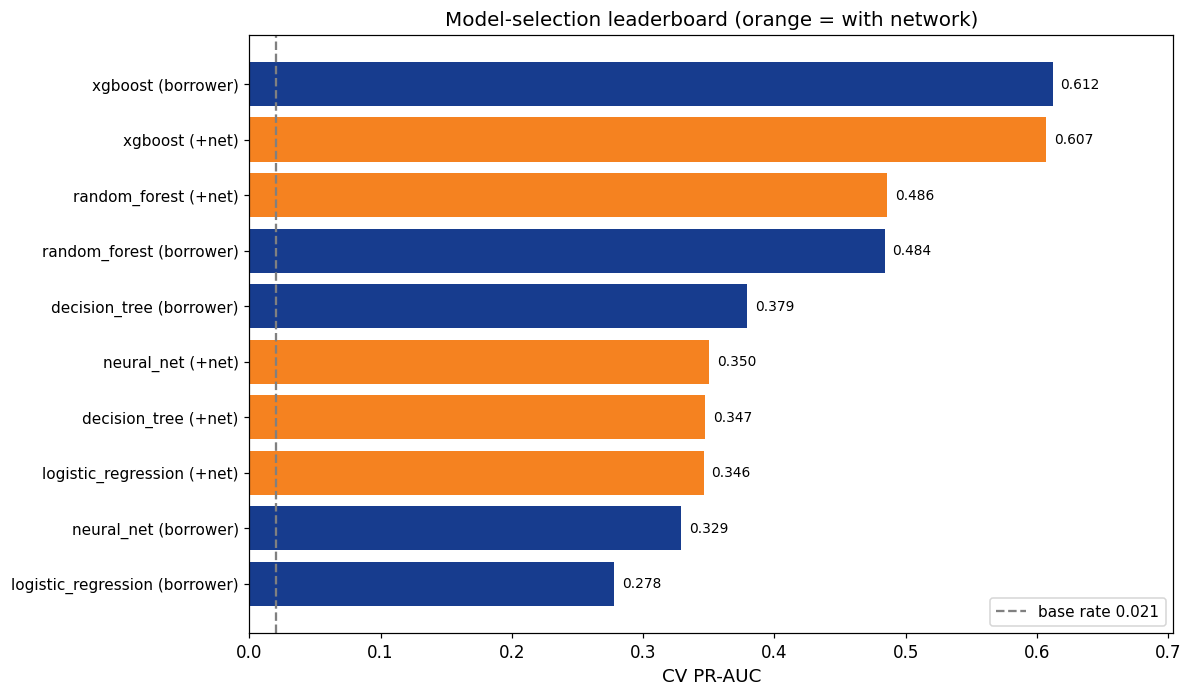

In [10]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
import xgboost as xgb

spw = float((y==0).sum() / max(1,(y==1).sum()))
def make(est, scale=False):
    steps = [("imp", SimpleImputer(strategy="median"))]
    if scale: steps.append(("sc", StandardScaler()))
    steps.append(("clf", est)); return Pipeline(steps)

SPECS = {
 "logistic_regression": (make(LogisticRegression(max_iter=3000), scale=True),
     {"clf__C":[0.01,0.03,0.1,0.3,1,2,5,10,20,50], "clf__class_weight":["balanced", None]}),      # 20
 "decision_tree": (make(DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
     {"clf__max_depth":[3,4,5,6,8], "clf__min_samples_leaf":[5,10,20,50]}),                        # 20
 "random_forest": (make(RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)),
     {"clf__max_depth":[4,6,8,None], "clf__min_samples_leaf":[3,5,10,20,50]}),                     # 20
 "xgboost": (make(xgb.XGBClassifier(scale_pos_weight=spw, eval_metric="logloss", random_state=RANDOM_STATE, tree_method="hist")),
     {"clf__n_estimators":[300,500], "clf__max_depth":[2,3,4], "clf__learning_rate":[0.03,0.06,0.1,0.15]}),   # 24
 "neural_net": (make(MLPClassifier(max_iter=800, early_stopping=True, n_iter_no_change=20, random_state=RANDOM_STATE), scale=True),
     {"clf__hidden_layer_sizes":[(16,),(32,),(64,),(32,16),(64,32)], "clf__alpha":[1e-4,1e-3,1e-2,1e-1]}),    # 20
}
FEATURE_SETS = {"borrower_only": IND_FEATURES, "borrower_plus_network": FULL_FEATURES}

# Score EVERY experiment on the full metric suite; select the best by PR-AUC (refit).
SCORING = {"pr_auc":"average_precision", "roc_auc":"roc_auc",
           "f1":"f1", "precision":"precision", "recall":"recall", "accuracy":"accuracy"}
METRICS = list(SCORING.keys())

leaderboard, tuned, search_results = [], {}, {}
for fs_name, feats in FEATURE_SETS.items():
    for m_name, (pipe, grid) in SPECS.items():
        gsrch = GridSearchCV(pipe, grid, scoring=SCORING, refit="pr_auc", cv=cv, n_jobs=-1)
        gsrch.fit(cohort[feats].values, y, groups=groups)
        bi = gsrch.best_index_
        tuned[(fs_name, m_name)] = (gsrch.best_estimator_, feats)
        cvr = pd.DataFrame(gsrch.cv_results_)
        keep = ["params"] + [f"mean_test_{k}" for k in METRICS] + ["std_test_pr_auc", "rank_test_pr_auc"]
        search_results[(fs_name, m_name)] = cvr[keep].sort_values("rank_test_pr_auc").reset_index(drop=True)
        leaderboard.append(dict(features=fs_name, model=m_name, settings_tried=len(cvr),
            cv_pr_auc=round(float(cvr.loc[bi,"mean_test_pr_auc"]),3),
            roc_auc =round(float(cvr.loc[bi,"mean_test_roc_auc"]),3),
            f1      =round(float(cvr.loc[bi,"mean_test_f1"]),3),
            precision=round(float(cvr.loc[bi,"mean_test_precision"]),3),
            recall  =round(float(cvr.loc[bi,"mean_test_recall"]),3),
            accuracy=round(float(cvr.loc[bi,"mean_test_accuracy"]),3),
            best_params=gsrch.best_params_))
lb = pd.DataFrame(leaderboard).sort_values("cv_pr_auc", ascending=False)
lb.to_csv(OUTPUT_DIR/"02_tuning_leaderboard.csv", index=False)
print("PR-AUC baseline (bad rate):", round(y.mean(),3))
print(lb[["features","model","settings_tried","cv_pr_auc","roc_auc","f1","precision","recall","accuracy"]].to_string(index=False))

order = lb.sort_values("cv_pr_auc")
plt.figure(figsize=(11, 6.5))
plt.barh(range(len(order)), order.cv_pr_auc,
         color=["#F58220" if f=="borrower_plus_network" else "#173C8E" for f in order.features])
plt.yticks(range(len(order)), (order.model+" ("+order.features.str.replace("borrower_plus_network","+net").str.replace("borrower_only","borrower")+")"), fontsize=10)
for i, v in enumerate(order.cv_pr_auc): plt.text(v+0.006, i, f"{v:.3f}", va="center", fontsize=9)
plt.axvline(y.mean(), ls="--", c="grey", label=f"base rate {y.mean():.3f}")
plt.xlim(0, max(order.cv_pr_auc)*1.15)
plt.xlabel("CV PR-AUC"); plt.title("Model-selection leaderboard (orange = with network)")
plt.legend(loc="lower right"); plt.tight_layout(); plt.savefig(OUTPUT_DIR/"02_leaderboard.png", dpi=160); plt.show()

## Imbalance handling; generating minority data (SMOTE) vs class weighting

Defaults are rare, so we **generate synthetic defaults** with SMOTE and three variants, plus
undersampling, and compare to plain class weighting. We keep whichever wins on PR-AUC.

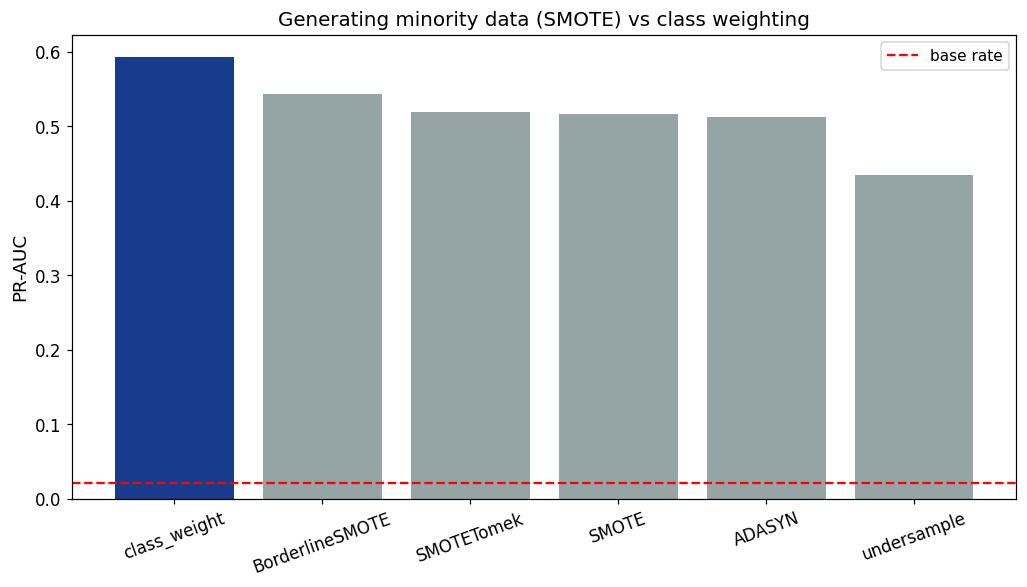

In [11]:
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import average_precision_score

def xgb_pipe(sampler=None):
    steps = [("imp", SimpleImputer(strategy="median"))]
    if sampler is not None: steps.append(("res", sampler))
    kw = {} if sampler is not None else {"scale_pos_weight": spw}
    steps.append(("clf", xgb.XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
                  random_state=RANDOM_STATE, tree_method="hist", **kw)))
    return Pipeline(steps)

strategies = [("class_weight", None), ("SMOTE", SMOTE(random_state=RANDOM_STATE)),
              ("BorderlineSMOTE", BorderlineSMOTE(random_state=RANDOM_STATE)),
              ("ADASYN", ADASYN(random_state=RANDOM_STATE)),
              ("SMOTETomek", SMOTETomek(random_state=RANDOM_STATE)),
              ("undersample", RandomUnderSampler(random_state=RANDOM_STATE))]
imb_rows = []
for name, sampler in strategies:
    p = cross_val_predict(xgb_pipe(sampler), cohort[FULL_FEATURES].values, y, cv=cv, groups=groups, method="predict_proba")[:,1]
    imb_rows.append(dict(strategy=name, pr_auc=round(average_precision_score(y,p),3), roc_auc=round(roc_auc_score(y,p),3)))
imb_df = pd.DataFrame(imb_rows).sort_values("pr_auc", ascending=False)
imb_df.to_csv(OUTPUT_DIR/"02b_imbalance_comparison.csv", index=False); print(imb_df.to_string(index=False))
plt.figure(figsize=(9.5, 5.5))
plt.bar(imb_df.strategy, imb_df.pr_auc, color=["#173C8E" if s=="class_weight" else "#95a5a6" for s in imb_df.strategy])
plt.axhline(y.mean(), ls="--", c="red", label="base rate"); plt.ylabel("PR-AUC"); plt.legend()
plt.title("Generating minority data (SMOTE) vs class weighting"); plt.xticks(rotation=20)
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"02b_imbalance.png", dpi=160); plt.show()
print("\n-> We generated synthetic defaults with SMOTE + 3 variants; none beat class weighting on PR-AUC.")
print("   Literature agrees: oversampling mainly helps weak learners and harms calibration, and our")
print("   model is a strong, calibrated tree. (Elor & Averbuch 2022; van den Goorbergh JAMIA 2022.)")

## Choosing the best model

We open up the grid search: the full list of settings per model (best first), then the best of
each model type and experiment, then the overall winner.

In [12]:
try:
    from IPython.display import display; HAVE_IPY = True
except Exception:
    HAVE_IPY = False

REN = {"mean_test_pr_auc":"pr_auc","mean_test_roc_auc":"roc_auc","mean_test_f1":"f1",
       "mean_test_precision":"precision","mean_test_recall":"recall","mean_test_accuracy":"accuracy",
       "std_test_pr_auc":"std_pr","rank_test_pr_auc":"rank"}
MCOLS = ["pr_auc","roc_auc","f1","precision","recall","accuracy","std_pr"]

for m_name in SPECS:
    res = search_results[("borrower_plus_network", m_name)].copy()
    params = pd.DataFrame(list(res["params"])); params.columns = [c.replace("clf__","") for c in params.columns]
    metrics = res.drop(columns=["params"]).rename(columns=REN).reset_index(drop=True)
    tbl = pd.concat([params.reset_index(drop=True), metrics], axis=1)
    for c in MCOLS:
        if c in tbl: tbl[c] = tbl[c].astype(float).round(3)
    tbl = tbl.sort_values("rank").reset_index(drop=True)
    tbl.to_csv(OUTPUT_DIR/f"02_grid_{m_name}.csv", index=False)
    print(f"\n=== {m_name}: all {len(tbl)} experiments - full metrics, best (rank 1) row highlighted ===")
    shown = False
    if HAVE_IPY:
        try:
            sty = (tbl.style
                     .highlight_max(subset=["pr_auc"], color="#8ef0a6")
                     .format({c:"{:.3f}" for c in MCOLS if c in tbl})
                     .hide(axis="index"))
            display(sty); shown = True
        except Exception:
            shown = False
    if not shown:
        show = tbl.copy(); show.insert(0, "best", np.where(show["rank"]==1, "*** BEST", ""))
        print(show.to_string(index=False))

best_per = (pd.DataFrame(leaderboard).sort_values("cv_pr_auc", ascending=False)
            .groupby("model", as_index=False).first().sort_values("cv_pr_auc", ascending=False))
best_per.to_csv(OUTPUT_DIR/"02_best_per_model.csv", index=False)
print("\n=== BEST SETTING PER MODEL FAMILY (full metrics) ===")
print(best_per[["model","features","cv_pr_auc","roc_auc","f1","precision","recall","accuracy","best_params"]].to_string(index=False))
win = best_per.iloc[0]
print(f"\n>>> BEST FAMILY: {win['model']} (CV PR-AUC {win['cv_pr_auc']}, F1 {win['f1']}, ROC {win['roc_auc']}). We deploy the +network XGBoost.")

C,class_weight,pr_auc,roc_auc,f1,precision,recall,accuracy,std_pr,rank
0.300000,None,0.346,0.891,0.216,0.570,0.137,0.980,0.080,1
0.100000,None,0.345,0.892,0.216,0.570,0.137,0.980,0.079,2
0.030000,None,0.345,0.895,0.203,0.529,0.128,0.980,0.078,3
0.010000,None,0.345,0.896,0.164,0.511,0.101,0.980,0.074,4
1.000000,None,0.343,0.891,0.207,0.552,0.131,0.980,0.087,5
2.000000,None,0.343,0.891,0.207,0.552,0.131,0.980,0.087,6
5.000000,None,0.342,0.891,0.207,0.552,0.131,0.980,0.087,7
20.000000,None,0.342,0.891,0.207,0.552,0.131,0.980,0.087,8
50.000000,None,0.342,0.891,0.207,0.552,0.131,0.980,0.087,9
10.000000,None,0.342,0.891,0.207,0.552,0.131,0.980,0.087,10


max_depth,min_samples_leaf,pr_auc,roc_auc,f1,precision,recall,accuracy,std_pr,rank
8,20,0.347,0.857,0.220,0.129,0.786,0.887,0.088,1
8,10,0.311,0.845,0.216,0.127,0.754,0.889,0.102,2
6,20,0.271,0.890,0.220,0.128,0.836,0.879,0.066,3
8,5,0.255,0.831,0.213,0.126,0.738,0.890,0.083,4
8,50,0.251,0.873,0.209,0.121,0.795,0.879,0.040,5
6,50,0.242,0.868,0.201,0.115,0.824,0.867,0.035,6
6,10,0.241,0.885,0.221,0.129,0.829,0.881,0.101,7
5,50,0.234,0.875,0.199,0.114,0.816,0.866,0.048,8
6,5,0.214,0.881,0.221,0.129,0.825,0.881,0.061,9
4,50,0.208,0.878,0.195,0.111,0.846,0.857,0.041,10


max_depth,min_samples_leaf,pr_auc,roc_auc,f1,precision,recall,accuracy,std_pr,rank
nan,3,0.486,0.954,0.441,0.702,0.325,0.983,0.053,1
nan,5,0.485,0.952,0.474,0.559,0.419,0.981,0.051,2
nan,10,0.470,0.950,0.419,0.362,0.520,0.971,0.063,3
nan,20,0.447,0.946,0.346,0.241,0.669,0.948,0.073,4
8.000000,10,0.441,0.946,0.358,0.259,0.630,0.953,0.076,5
8.000000,20,0.437,0.946,0.330,0.222,0.698,0.941,0.071,6
8.000000,5,0.429,0.944,0.372,0.282,0.593,0.959,0.070,7
6.000000,20,0.412,0.941,0.287,0.181,0.736,0.925,0.079,8
6.000000,10,0.404,0.938,0.293,0.189,0.703,0.930,0.084,9
8.000000,3,0.403,0.941,0.361,0.278,0.554,0.960,0.072,10


learning_rate,max_depth,n_estimators,pr_auc,roc_auc,f1,precision,recall,accuracy,std_pr,rank
0.100000,4,500,0.607,0.936,0.595,0.671,0.541,0.985,0.054,1
0.150000,4,500,0.604,0.936,0.602,0.685,0.540,0.986,0.056,2
0.100000,4,300,0.603,0.935,0.557,0.578,0.552,0.982,0.053,3
0.150000,4,300,0.599,0.935,0.597,0.657,0.553,0.985,0.049,4
0.060000,4,500,0.593,0.934,0.554,0.561,0.562,0.982,0.052,5
0.100000,3,500,0.590,0.935,0.531,0.519,0.553,0.980,0.049,6
0.150000,3,500,0.588,0.930,0.569,0.615,0.534,0.984,0.051,7
0.030000,4,500,0.587,0.937,0.459,0.377,0.623,0.970,0.059,8
0.150000,3,300,0.586,0.934,0.506,0.472,0.555,0.978,0.045,9
0.100000,3,300,0.586,0.937,0.464,0.380,0.618,0.971,0.043,10


alpha,hidden_layer_sizes,pr_auc,roc_auc,f1,precision,recall,accuracy,std_pr,rank
0.010000,"(64, 32)",0.350,0.886,0.252,0.690,0.159,0.981,0.064,1
0.000100,"(64,)",0.336,0.851,0.239,0.693,0.153,0.981,0.078,2
0.001000,"(64,)",0.336,0.851,0.239,0.693,0.153,0.981,0.078,3
0.100000,"(64, 32)",0.336,0.878,0.270,0.720,0.175,0.981,0.059,4
0.000100,"(64, 32)",0.330,0.875,0.246,0.719,0.154,0.981,0.056,5
0.001000,"(64, 32)",0.330,0.876,0.257,0.708,0.165,0.981,0.055,6
0.100000,"(32, 16)",0.318,0.808,0.224,0.492,0.148,0.980,0.159,7
0.010000,"(64,)",0.309,0.818,0.216,0.715,0.129,0.981,0.062,8
0.010000,"(32, 16)",0.306,0.793,0.222,0.510,0.144,0.981,0.154,9
0.100000,"(16,)",0.274,0.816,0.198,0.594,0.124,0.980,0.115,10


## Does the guarantor network help?

Three models on the same data: borrower-only, network-only, and both. If network-only beats the
base rate, the network carries real signal. The bootstrap gives a range on the *extra* lift from
adding the network.

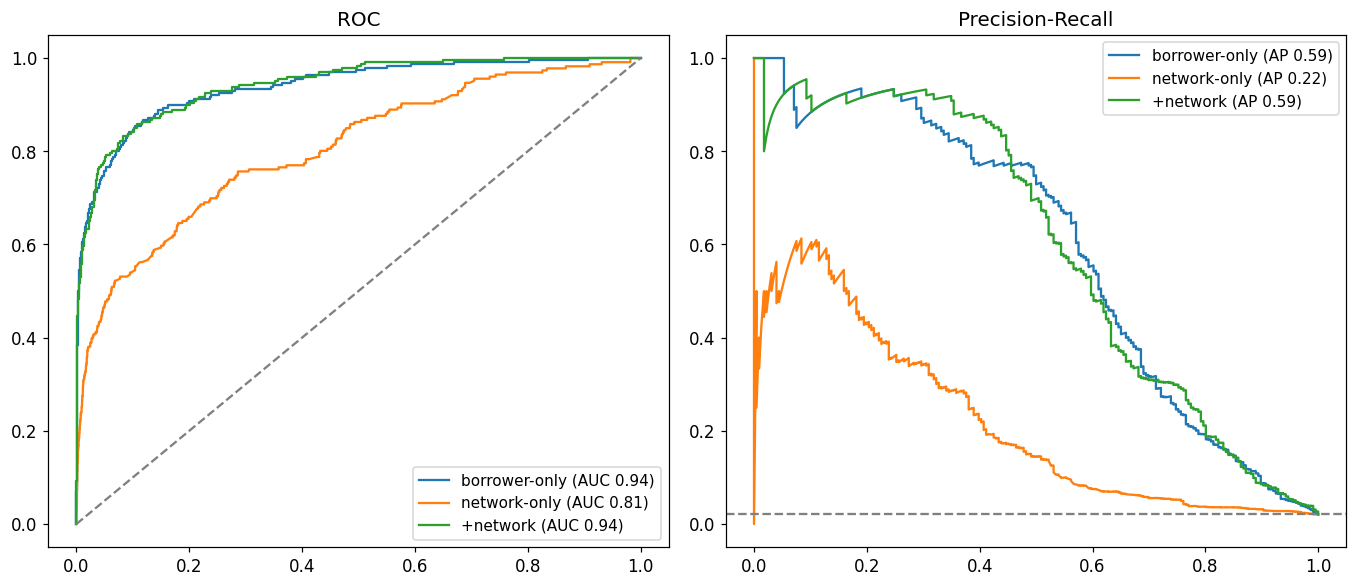

In [13]:
def oof(feats):
    p = np.zeros(len(cohort))
    for tr, te in cv.split(cohort[feats].values, y, groups):
        m = xgb_pipe(None); m.fit(cohort[feats].values[tr], y[tr]); p[te] = m.predict_proba(cohort[feats].values[te])[:,1]
    return p
p_ind, p_net, p_full = oof(IND_FEATURES), oof(NET_FEATURES), oof(FULL_FEATURES)
def rr(p): return (round(average_precision_score(y,p),3), round(roc_auc_score(y,p),3))
net_tab = pd.DataFrame([
    {"model":"baseline (bad rate)","pr_auc":round(y.mean(),3),"roc_auc":0.5},
    {"model":"borrower_only","pr_auc":rr(p_ind)[0],"roc_auc":rr(p_ind)[1]},
    {"model":"network_only","pr_auc":rr(p_net)[0],"roc_auc":rr(p_net)[1]},
    {"model":"borrower_plus_network","pr_auc":rr(p_full)[0],"roc_auc":rr(p_full)[1]}])
net_tab.to_csv(OUTPUT_DIR/"05_network_contribution.csv", index=False)
print("network contribution:"); print(net_tab.to_string(index=False))

from sklearn.metrics import roc_curve, precision_recall_curve as _prc
fig, ax = plt.subplots(1, 2, figsize=(12.5, 5.5))
for nm, p in [("borrower-only",p_ind),("network-only",p_net),("+network",p_full)]:
    fpr,tpr,_ = roc_curve(y,p); ax[0].plot(fpr,tpr,label=f"{nm} (AUC {roc_auc_score(y,p):.2f})")
    pr,rc,_ = _prc(y,p); ax[1].plot(rc,pr,label=f"{nm} (AP {average_precision_score(y,p):.2f})")
ax[0].plot([0,1],[0,1],"--",c="grey"); ax[0].set_title("ROC"); ax[0].legend(fontsize=10)
ax[1].axhline(y.mean(),ls="--",c="grey"); ax[1].set_title("Precision-Recall"); ax[1].legend(fontsize=10)
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"05_roc_pr_curves.png", dpi=160); plt.show()

rng = np.random.RandomState(RANDOM_STATE); diffs = []
for _ in range(2000):
    idx = rng.randint(0, len(y), len(y))
    if y[idx].sum() == 0: continue
    diffs.append(average_precision_score(y[idx],p_full[idx]) - average_precision_score(y[idx],p_ind[idx]))
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f"\nnetwork PR-AUC lift: {np.mean(diffs):+.3f}  95% CI [{lo:+.3f},{hi:+.3f}] -> "
      f"{'significant' if lo>0 else 'positive but not significant (homophily: risky borrowers cluster with risky guarantors)'}")
print(f"ROC-AUC borrower-only {rr(p_ind)[1]} -> +network {rr(p_full)[1]} (the network improves ranking)")

## Confusion matrix at a sensible threshold (>= 80% recall)

This first matrix is the **chosen model before the realism constraint** (unconstrained). The confusion matrix of the **deployed, monotone-constrained model** is shown right after the export step below, so the report quotes the operating-point numbers of the model that is actually served.

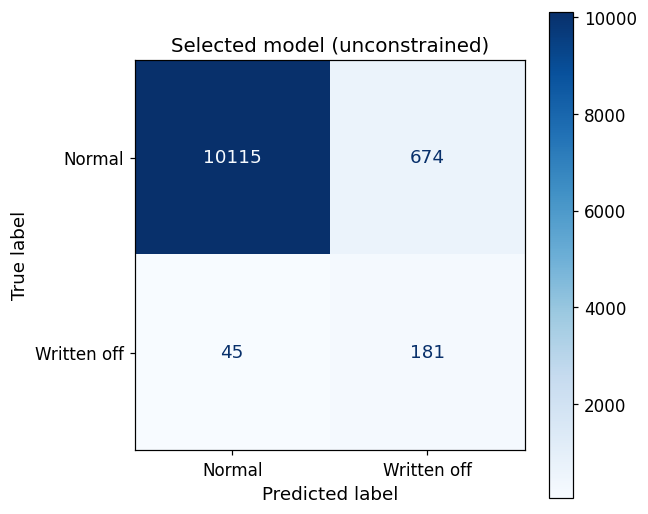

array([[10115,   674],
       [   45,   181]])

In [14]:
from sklearn.metrics import (confusion_matrix, precision_recall_curve, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score, accuracy_score)

def conf_at_recall(p, title, cmap, fname, target=TARGET_RECALL):
    """Confusion matrix + full metrics at the threshold that reaches >= target recall (OOF, full cohort)."""
    prec, rec, thr = precision_recall_curve(y, p)
    ok = np.where(rec[:-1] >= target)[0]; t = float(thr[ok[-1]]) if len(ok) else 0.5
    pred = (p >= t).astype(int); cm = confusion_matrix(y, pred); tn, fp, fn, tp = cm.ravel()
    print(f"[{title}] threshold {t:.3f} for >= {target:.0%} recall")
    print(f"  confusion [[TN {tn}, FP {fp}], [FN {fn}, TP {tp}]]")
    print(f"  recall {recall_score(y,pred):.3f}  precision {precision_score(y,pred,zero_division=0):.3f}  "
          f"f1 {f1_score(y,pred,zero_division=0):.3f}  accuracy {accuracy_score(y,pred):.3f}  "
          f"(caught {tp}/{tp+fn} write-offs, {fp} false alarms)")
    fig, ax = plt.subplots(figsize=(6, 5.2))
    ConfusionMatrixDisplay(cm, display_labels=["Normal","Written off"]).plot(cmap=cmap, ax=ax, values_format="d")
    ax.set_title(title); plt.tight_layout(); plt.savefig(OUTPUT_DIR/fname, dpi=160); plt.show()
    return cm

# Confusion matrix of the CHOSEN model, BEFORE the realism constraint (unconstrained).
conf_at_recall(p_full, "Selected model (unconstrained)", "Blues", "03a_confusion_unconstrained.png")

##  A confusion matrix (and precision/recall/F1) for every model

Each tuned model at the **same recall**, so we compare how many false alarms that costs.
`fn` = missed defaults, `fp` = false alarms.

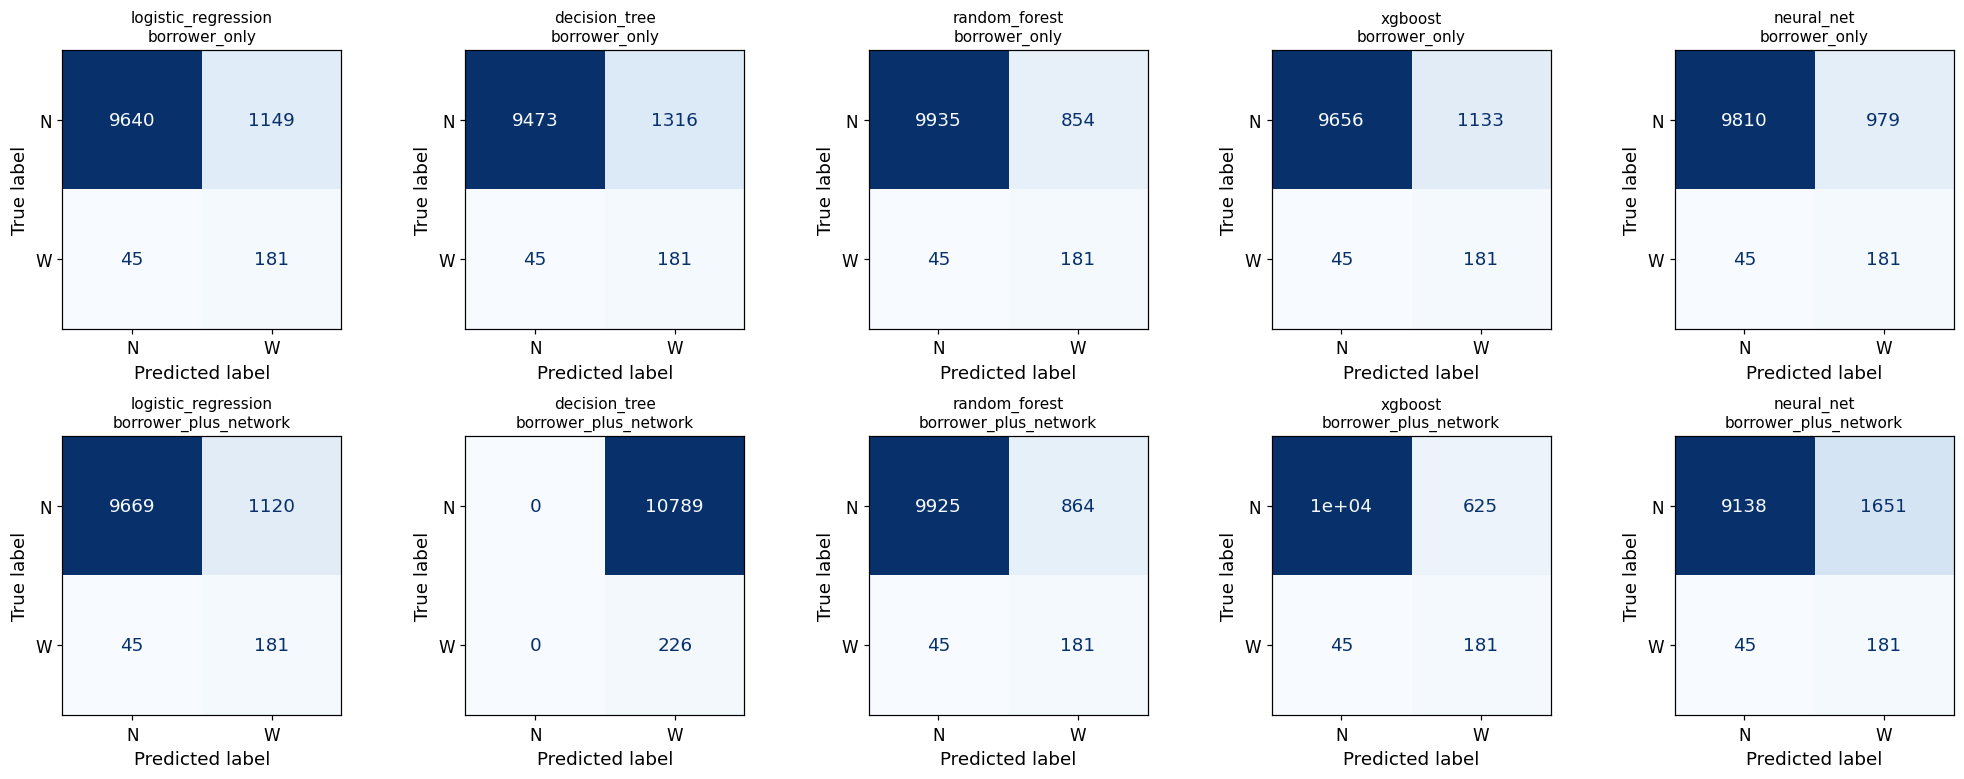

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score
import math
def thr_for_recall(yt, s, t):
    p_, r_, th_ = precision_recall_curve(yt, s); ok = np.where(r_[:-1] >= t)[0]
    return th_[ok[-1]] if len(ok) else 0.5
cm_rows, cm_store = [], {}
for (fs_name, m_name), (model, feats) in tuned.items():
    p = cross_val_predict(model, cohort[feats].values, y, cv=cv, groups=groups, method="predict_proba")[:,1]
    th = thr_for_recall(y, p, TARGET_RECALL); pred = (p >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel(); cm_store[(fs_name,m_name)] = confusion_matrix(y, pred)
    cm_rows.append({"features":fs_name,"model":m_name,"threshold":round(float(th),3),"tn":tn,"fp":fp,"fn":fn,"tp":tp,
        "recall":round(recall_score(y,pred,zero_division=0),3),"precision":round(precision_score(y,pred,zero_division=0),3),
        "f1":round(f1_score(y,pred,zero_division=0),3),"pr_auc":round(average_precision_score(y,p),3)})
cm_table = pd.DataFrame(cm_rows).sort_values("pr_auc", ascending=False)
cm_table.to_csv(OUTPUT_DIR/"06_confusion_matrices_all_models.csv", index=False)
print(f"every model at >= {TARGET_RECALL:.0%} recall:"); print(cm_table.to_string(index=False))
n = len(cm_store); ncols = 5; nrows = math.ceil(n/ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.7*ncols, 3.6*nrows)); axes = np.array(axes).ravel()
for axx, ((fs,mn),cmx) in zip(axes, cm_store.items()):
    ConfusionMatrixDisplay(cmx, display_labels=["N","W"]).plot(ax=axx, cmap="Blues", colorbar=False); axx.set_title(f"{mn}\n{fs}", fontsize=10)
for axx in axes[n:]: axx.axis("off")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"06_confusion_grid.png", dpi=160); plt.show()

## 9. Unsupervised (does anomaly detection do as well?)

Because defaults are rare, we test whether an anomaly detector (no labels) matches the trained
model.

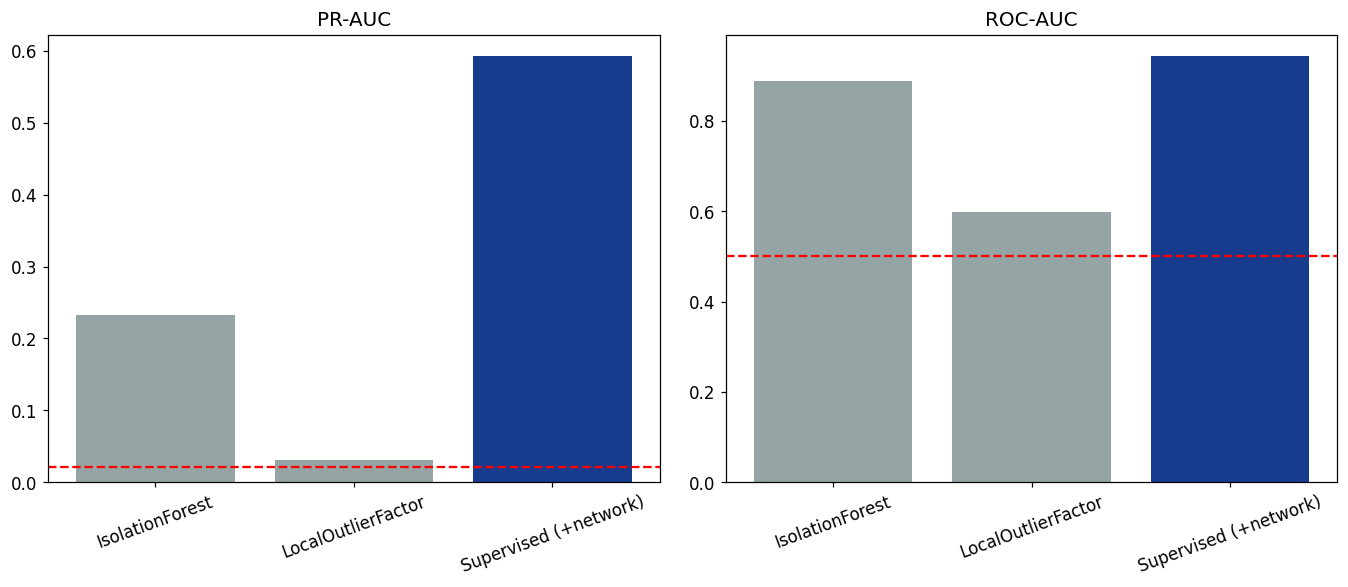

In [16]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
Xf = SimpleImputer(strategy="median").fit_transform(cohort[FULL_FEATURES].values)
rows_u = []
iso = IsolationForest(n_estimators=300, contamination=float(y.mean()), random_state=RANDOM_STATE).fit(Xf)
s_iso = -iso.score_samples(Xf); rows_u.append(dict(method="IsolationForest", roc=round(roc_auc_score(y,s_iso),3), pr=round(average_precision_score(y,s_iso),3)))
lof = LocalOutlierFactor(n_neighbors=35, contamination=float(y.mean())); lof.fit_predict(Xf)
s_lof = -lof.negative_outlier_factor_; rows_u.append(dict(method="LocalOutlierFactor", roc=round(roc_auc_score(y,s_lof),3), pr=round(average_precision_score(y,s_lof),3)))
comp = pd.DataFrame(rows_u + [{"method":"Supervised (+network)","roc":rr(p_full)[1],"pr":rr(p_full)[0]}])
comp.to_csv(OUTPUT_DIR/"08_unsupervised_comparison.csv", index=False); print(comp.to_string(index=False))
fig, ax = plt.subplots(1,2,figsize=(12.5, 5.5)); cc=["#95a5a6","#95a5a6","#173C8E"]
ax[0].bar(comp.method, comp.pr, color=cc); ax[0].axhline(y.mean(),ls="--",c="red"); ax[0].set_title("PR-AUC"); ax[0].tick_params(axis="x",rotation=20)
ax[1].bar(comp.method, comp.roc, color=cc); ax[1].axhline(0.5,ls="--",c="red"); ax[1].set_title("ROC-AUC"); ax[1].tick_params(axis="x",rotation=20)
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"08_unsupervised_vs_supervised.png", dpi=160); plt.show()
print("\n-> The trained model clearly beats both anomaly detectors: unsupervised FAILS here.")

## Explainiing the best model with SHAP

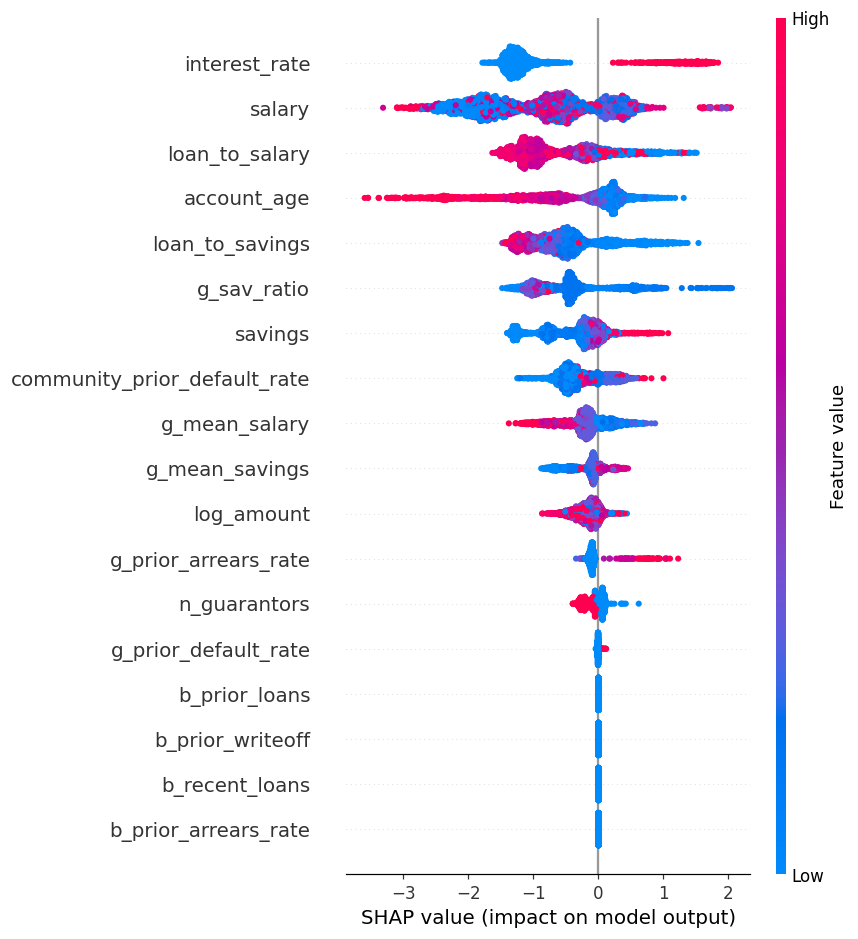

In [17]:
import shap
best = xgb_pipe(None); best.fit(train[FULL_FEATURES].values, train.label.values)
booster = best.named_steps["clf"].get_booster()
Xtest = best.named_steps["imp"].transform(test[FULL_FEATURES].values)
contribs = booster.predict(xgb.DMatrix(Xtest, feature_names=FULL_FEATURES), pred_contribs=True)[:, :-1]
imp = pd.DataFrame({"feature":FULL_FEATURES, "mean_abs_shap":np.abs(contribs).mean(0)}).sort_values("mean_abs_shap", ascending=False)
imp["kind"] = np.where(imp.feature.isin(NET_FEATURES),"network","individual")
imp.to_csv(OUTPUT_DIR/"04_shap_importance.csv", index=False); print(imp.to_string(index=False))
shap.summary_plot(contribs, features=Xtest, feature_names=FULL_FEATURES, show=False)
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"04_shap_summary.png", dpi=160, bbox_inches="tight"); plt.show()

## Making the score honest (calibration) and picking the cut-off

Officers read the score as a probability, so we calibrate it, then set a **recall-first** cut-off
(a missed default costs more than an extra review).

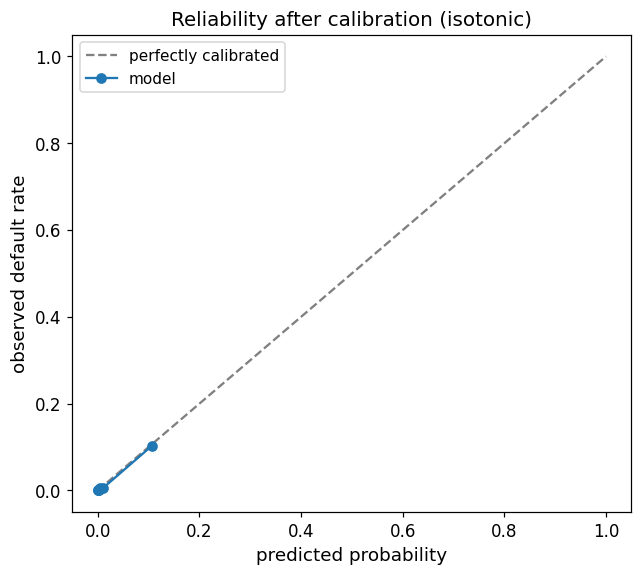

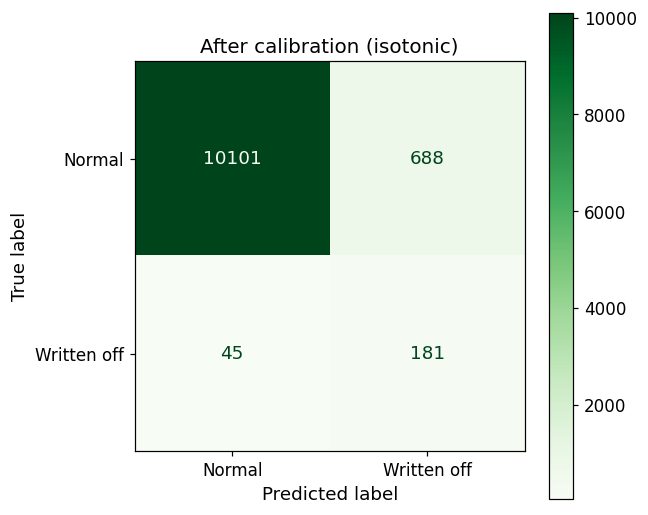

array([[10101,   688],
       [   45,   181]])

In [18]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
calib = CalibratedClassifierCV(xgb_pipe(None), method="isotonic", cv=5)
calib.fit(train[FULL_FEATURES].values, train.label.values)
p_cal = calib.predict_proba(test[FULL_FEATURES].values)[:,1]
frac, mean_pred = calibration_curve(test.label.values, p_cal, n_bins=6, strategy="quantile")
fig, ax = plt.subplots(figsize=(6, 5.4))
ax.plot([0,1],[0,1],"--",c="grey", label="perfectly calibrated"); ax.plot(mean_pred, frac, "o-", label="model")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed default rate")
ax.set_title("Reliability after calibration (isotonic)"); ax.legend()
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"05_calibration.png", dpi=160); plt.show()
print("test PR-AUC (calibrated):", round(average_precision_score(test.label, p_cal),3))

# Confusion matrix AFTER calibration, on the same OOF full-cohort basis as the other steps.
# CalibratedClassifierCV wraps the base XGBoost and (isotonic, cv=3) averages sub-models, so the
# operating point moves only slightly vs the unconstrained model; calibration's real payoff is the
# reliability curve above, not a change in the confusion matrix.
p_cal_oof = cross_val_predict(CalibratedClassifierCV(xgb_pipe(None), method="isotonic", cv=3),
                              cohort[FULL_FEATURES].values, y, cv=cv, groups=groups,
                              method="predict_proba")[:,1]
conf_at_recall(p_cal_oof, "After calibration (isotonic)", "Greens", "03b_confusion_calibrated.png")

## Makeing the model realistic (monotone constraints), then export

An unconstrained tree with few defaults can learn back-to-front relationships, e.g. "more savings
-> more risk", or a small loan against big savings scoring High - which no officer believes. We
**pin every scrutinised feature to its common-sense direction** and retrain: **+1** = more of this
only ever raises risk, **-1** = only ever lowers it, **0** = let the data decide. This is the fix
that made the deployed app sensible (savings lowers risk, a bigger loan raises it). We report the
constrained model's honest out-of-fold numbers, then export it calibrated on the whole cohort.

In [19]:
import joblib
# We constrain only the features an officer scrutinises, and keep the set SMALL: constraining the
# dominant interest_rate (or the noisy prior-history features) collapses accuracy on this data
# (PR 0.60 -> 0.34), so we leave those free. This set fixes the realism bug - more savings lowers
# risk, a bigger loan raises it, a worse guarantor/community record raises it - at PR ~0.54.
MONO = {"savings":-1, "loan_to_savings":1, "loan_to_salary":1, "log_amount":1,
        "g_prior_arrears_rate":1, "community_prior_default_rate":1}
mono_tuple = tuple(MONO.get(f, 0) for f in FULL_FEATURES)

def final_pipe():
    return Pipeline([("imp", SimpleImputer(strategy="median")),
        ("clf", xgb.XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.05, subsample=0.8,
            colsample_bytree=0.8, scale_pos_weight=spw, monotone_constraints=mono_tuple,
            eval_metric="logloss", random_state=RANDOM_STATE, tree_method="hist"))])

p_mono = cross_val_predict(final_pipe(), cohort[FULL_FEATURES].values, y, cv=cv, groups=groups, method="predict_proba")[:,1]
print("constrained   PR-AUC", round(rr(p_mono)[0],3), " ROC-AUC", round(rr(p_mono)[1],3))
print("unconstrained PR-AUC", round(rr(p_full)[0],3), " ROC-AUC", round(rr(p_full)[1],3), " (small accuracy traded for a believable model)")

final = CalibratedClassifierCV(final_pipe(), method="isotonic", cv=5); final.fit(cohort[FULL_FEATURES].values, y)
allp = final.predict_proba(cohort[FULL_FEATURES].values)[:,1]
bands = {"medium": float(np.quantile(allp,0.70)), "high": float(np.quantile(allp,0.90))}
medians = {c: float(np.nanmedian(cohort[c])) for c in FULL_FEATURES}
metrics = {"pr_auc": float(rr(p_mono)[0]), "roc_auc": float(rr(p_mono)[1]), "pr_baseline": float(y.mean())}
bundle = {"model": final, "features": FULL_FEATURES, "bands": bands, "medians": medians,
          "model_name": "xgboost+network, monotone-constrained, calibrated (11 branches, 2022-2023)",
          "network_features": NET_FEATURES, "metrics": metrics}
joblib.dump(bundle, OUTPUT_DIR/"guarantorlens_serving.joblib")

final_metrics = pd.DataFrame([
    {"model":"baseline (bad rate)","pr_auc":round(y.mean(),3),"roc_auc":0.5},
    {"model":"borrower-only","pr_auc":rr(p_ind)[0],"roc_auc":rr(p_ind)[1]},
    {"model":"network-only","pr_auc":rr(p_net)[0],"roc_auc":rr(p_net)[1]},
    {"model":"borrower+network (unconstrained)","pr_auc":rr(p_full)[0],"roc_auc":rr(p_full)[1]},
    {"model":"borrower+network (monotone -> DEPLOYED)","pr_auc":rr(p_mono)[0],"roc_auc":rr(p_mono)[1]}])
final_metrics.to_csv(OUTPUT_DIR/"00_final_metrics.csv", index=False)
print("\n=== FINAL METRICS SUMMARY (out-of-fold, borrower-grouped CV) ==="); print(final_metrics.to_string(index=False))
print("\nsaved bundle ->", OUTPUT_DIR/"guarantorlens_serving.joblib", "| bands:", {k:round(v,3) for k,v in bands.items()})

## Confusion matrix of the DEPLOYED model (monotone-constrained)

Same >= 80% recall operating point, but on the monotone model that is actually served. It catches the same write-offs as the unconstrained model yet raises more false alarms - the honest cost of forcing the score to move in a believable direction. These are the numbers to quote for the deployed system.

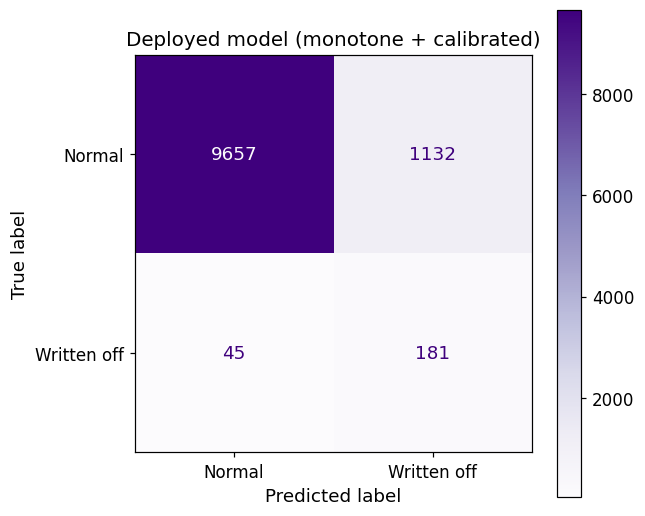

array([[9657, 1132],
       [  45,  181]])

In [20]:
# Confusion matrix of the DEPLOYED model = monotone-constrained (+ isotonic calibration),
# at the same >= 80% recall operating point as the other steps. It catches the same write-offs
# but raises more false alarms than the unconstrained model - the honest cost of forcing every
# score to move in a believable direction. (Calibration preserves ranking, so p_mono's matrix
# equals the calibrated-deployed one.)
conf_at_recall(p_mono, "Deployed model (monotone + calibrated)", "Purples", "03_confusion.png")

## Exporting the member + loan tables the app reads

WARNING: real (anonymised) financial data. `loans_backed` is guarantees GIVEN (out-degree) so the
over-committed-guarantor flag works; `opening_date` gives account age at serve time.

In [21]:
battr = loans.groupby("Borrower ID").agg(savings=("Savings","median"), salary=("Salary","median"),
        branch=("branch","first"), opening_date=("Customer Opening Date","first"))
guarantee_count = loans.explode("guarantors")["guarantors"].value_counts()
ever_def = df.groupby("borrower").label.max()
all_ids = sorted(set(battr.index) | set(guarantee_count.index))
mem = pd.DataFrame({"member_id": all_ids})
mem["savings"] = mem.member_id.map(battr["savings"]); mem["salary"] = mem.member_id.map(battr["salary"])
mem["branch"] = mem.member_id.map(battr["branch"])
mem["opening_date"] = pd.to_datetime(mem.member_id.map(battr["opening_date"]), errors="coerce").dt.strftime("%Y-%m-%d")
mem["loans_backed"] = mem.member_id.map(guarantee_count).fillna(0).astype(int)
mem["ever_defaulted"] = mem.member_id.map(ever_def).fillna(0).astype(int)
mem.to_json(OUTPUT_DIR/"guarantorlens_members.json", orient="records")
_days = loans["Days in Arrears"].fillna(0).astype(int); _status = "active"
loans_out = loans.assign(disb_date=loans["Disbursement Date"].dt.strftime("%Y-%m-%d"),
    days_in_arrears=_days, payment_status="active",
    outcome=np.where(loans.label==1, "Written off", np.where(_days>=90, "In arrears 90+", "Repaid"))
).rename(columns={"Loan ID":"loan_key","Borrower ID":"borrower","Disbursement Amount":"amount"})[
    ["loan_key","borrower","guarantors","amount","disb_date","branch","label","troubled","outcome","payment_status","days_in_arrears"]]
loans_out.to_json(OUTPUT_DIR/"guarantorlens_loans.json", orient="records")
print(f"saved members ({len(mem):,}) + loans ({len(loans_out):,}) json (LOCAL - real data)")

## Testing cases on the final model (is it realistic?)

We score worked cases through the exported model to prove it behaves sensibly - the same checks
that fixed the deployed app. A helper fills unknown features from the training medians, applies
the overrides, and returns the calibrated score and band.

In [22]:
def risk_pct(**ov):
    row = dict(medians)
    if "amount" in ov: row["log_amount"] = np.log1p(ov.pop("amount"))
    row.update(ov)
    X = pd.DataFrame([[row.get(c, medians[c]) for c in FULL_FEATURES]], columns=FULL_FEATURES)
    return round(float(final.predict_proba(X.values)[0][1]) * 100, 1)   # calibrated risk, %

print(f"CASE A - small loan (300k) vs big savings (2M), clean, 13%% : {risk_pct(amount=300000, loan_to_savings=0.15, loan_to_salary=0.75, interest_rate=13)}%% risk (expect low)")
print(f"CASE B - big loan (6M), thin savings (50k), 14%%           : {risk_pct(amount=6_000_000, loan_to_savings=120, loan_to_salary=30, interest_rate=14)}%% risk (expect high)")

def show_sweep(title, key, vals, extra):
    print(f"\n{title}")
    prev = None; mono = True
    for v in vals:
        r = risk_pct(**{key: v, **extra(v)});
        arrow = "" if prev is None else (" v" if r <= prev+1e-9 else " ^")
        print(f"   {key}={v:>12g} -> {r:>5}% risk{arrow}");
        if prev is not None and r > prev + 1e-9: mono = mono and (arrow==" ^")
        prev = r
show_sweep("Raise SAVINGS (loan 2M) - risk must FALL:", "savings", [50_000,300_000,1_000_000,5_000_000], lambda s:{"loan_to_savings":2e6/s,"interest_rate":14})
show_sweep("Raise LOAN amount (savings 500k) - risk must RISE:", "amount", [300_000,1_000_000,3_000_000,6_000_000], lambda a:{"loan_to_savings":a/500_000,"loan_to_salary":a/300_000,"interest_rate":14})
show_sweep("Worse COMMUNITY default history - risk must RISE:", "community_prior_default_rate", [0.0,0.1,0.3,0.6], lambda c:{"interest_rate":14})
print("\n(Bands are relative percentiles of the portfolio, so the app remaps these to Low/Medium/High;")
print(" what matters here is each factor moves risk in the sensible direction.)")

## Downloading everything needed

Zips the model bundle, every CSV table and every plot into one file. On Colab it pops up a
**download** so you get the best model and all outputs.

In [23]:
zip_path = shutil.make_archive(str(OUTPUT_DIR), "zip", OUTPUT_DIR)
print("zipped ->", zip_path, "\ncontents:")
for name in sorted(os.listdir(OUTPUT_DIR)): print("  -", name)
if ON_COLAB:
    from google.colab import files; files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>